# Ampere Analysis Notebook

This notebook demonstrates how to load HPL traces using the `ampere` library and visualize energy consumption.
Now running on **Arkouda** for scalable server-side processing.

In [1]:
from IPython.display import display
import re
from ampere import Ensemble, MetricConfig, MetricType, AmpereSession, Visualizer, connect
import arkouda as ak
import pandas as pd
# Connect to Arkouda (registers cleanup automatically)
connect(server="localhost", port=5555)

    _         _                   _       
   / \   _ __| | _____  _   _  __| | __ _ 
  / _ \ | '__| |/ / _ \| | | |/ _` |/ _` |
 / ___ \| |  |   < (_) | |_| | (_| | (_| |
/_/   \_\_|  |_|\_\___/ \__,_|\__,_|\__,_|
                                          

Client Version: v2025.07.03+64.gd6838bfbe


connected to arkouda server tcp://*:5555


Connecting to Arkouda server at localhost:5555...


In [2]:
# Define Metric Configs
configs = {
    re.compile(r".*rocm.*energy.*"): MetricConfig(MetricType.CUMULATIVE, scale_factor=1e-6),
    re.compile(r".*rocm.*power.*"): MetricConfig(MetricType.INSTANTANEOUS, scale_factor=1e-6),
}

# Define Topology Resolver
def my_hpc_topology(metric_name, ranks):
    if 'device=4' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 0', 'MPI Rank 1']]
    if 'device=2' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 2', 'MPI Rank 3']]
    if 'device=6' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 4', 'MPI Rank 5']]
    if 'device=0' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 6', 'MPI Rank 7']]
    return ranks

In [3]:
ranks = [f"MPI Rank {i}" for i in range(8)]
topo = {"Node0": ranks}
ensemble = Ensemble.from_trace_paths(["./hpl-with-wrapper-trace"], topo, configs)


Loading Runs:   0%|          | 0/1 [00:00<?, ?it/s]

Loading Runs: 100%|██████████| 1/1 [00:19<00:00, 19.14s/it]

Loading Runs: 100%|██████████| 1/1 [00:19<00:00, 19.14s/it]

In [4]:
# 2. Get Average Power from Cumulative Energy Metric (using 'rate')
df_energy_rate = ak.DataFrame.concat([
    ensemble.attribute(
        metric,
        topology_resolver=my_hpc_topology,
        output_mode='rate',
        strategy='exclusive'
    ) for metric in ["A2rocm_smi:::energy_count:device=0", "A2rocm_smi:::energy_count:device=2", "A2rocm_smi:::energy_count:device=4", "A2rocm_smi:::energy_count:device=6"]
])
avg_energy_rate = df_energy_rate['Value'].mean()
print(f"Average Power (from Energy Metric): {avg_energy_rate:.2f} W")

Attributing 'A2rocm_smi:::energy_count:device=0' on Arkouda Server...


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:04<00:00,  4.76s/it]

100%|██████████| 1/1 [00:04<00:00,  4.76s/it]

Attributing 'A2rocm_smi:::energy_count:device=2' on Arkouda Server...


...

Attributing 'A2rocm_smi:::energy_count:device=6' on Arkouda Server...


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:04<00:00,  4.75s/it]

100%|██████████| 1/1 [00:04<00:00,  4.75s/it]

Average Power (from Energy Metric): 136.47 W


In [5]:
df_joules = ak.DataFrame.concat([
    ensemble.attribute(
        metric,
        topology_resolver=my_hpc_topology,
        strategy='exclusive'
    ) for metric in ["A2rocm_smi:::energy_count:device=0", "A2rocm_smi:::energy_count:device=2", "A2rocm_smi:::energy_count:device=4", "A2rocm_smi:::energy_count:device=6"]
])
print("Attribution complete.")

Attributing 'A2rocm_smi:::energy_count:device=0' on Arkouda Server...


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:04<00:00,  4.73s/it]

100%|██████████| 1/1 [00:04<00:00,  4.73s/it]

Attributing 'A2rocm_smi:::energy_count:device=2' on Arkouda Server...


...

Attributing 'A2rocm_smi:::energy_count:device=6' on Arkouda Server...


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:04<00:00,  4.79s/it]

100%|██████████| 1/1 [00:04<00:00,  4.79s/it]

Attribution complete.


Profiling time on Arkouda Server...


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:25<00:00, 25.95s/it]

100%|██████████| 1/1 [00:25<00:00, 25.95s/it]

This transfer will use 551 MB .


This transfer will use 551 MB .


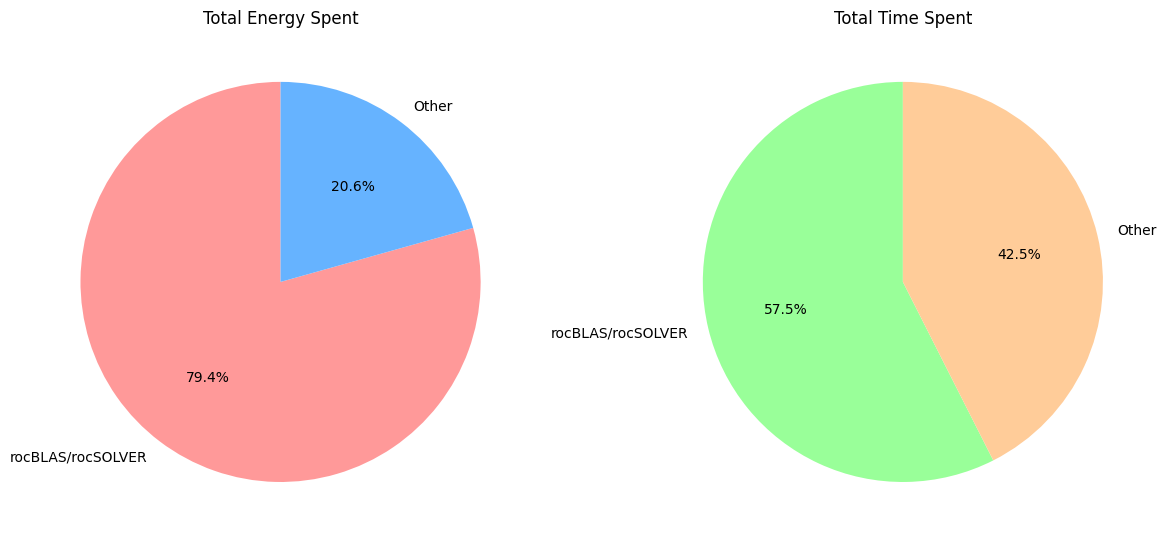

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

time_profile = ensemble.time_profile(topology_resolver=my_hpc_topology, strategy='exclusive')

# Get the total time spent in ROCBLAS or ROCSOLVER
time_profile_pd = time_profile.to_pandas()
time_mask = time_profile_pd['Name'].str.contains('rocblas|rocsolver', case=False)
total_time = time_profile_pd['Value'].sum()
time_in_rocblas = time_profile_pd[time_mask]['Value'].sum()
other_time = total_time - time_in_rocblas

# Do the same for energy
energy_pd = df_joules.to_pandas()
energy_mask = energy_pd['Name'].str.contains('rocblas|rocsolver', case=False)
total_energy = energy_pd['Value'].sum()
energy_in_rocblas = energy_pd[energy_mask]['Value'].sum()
other_energy = total_energy - energy_in_rocblas

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.pie([energy_in_rocblas, other_energy], labels=['rocBLAS/rocSOLVER', 'Other'], autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
ax1.set_title('Total Energy Spent')

ax2.pie([time_in_rocblas, other_time], labels=['rocBLAS/rocSOLVER', 'Other'], autopct='%1.1f%%', startangle=90, colors=['#99ff99','#ffcc99'])
ax2.set_title('Total Time Spent')

plt.tight_layout()
plt.show()


In [7]:
display(df_joules.sort_values(by="Value", ascending=False).head(20).to_pandas())

,Start Time,End Time,Name,Depth,Value,Rank,Node,Run
0,0.218488,14.383370,HPL_InitGPU(HPL_S_grid const*),1,699.138686,MPI Rank 0,Node0,hpl-with-wrapper-trace
1,0.218487,10.668842,HPL_InitGPU(HPL_S_grid const*),1,520.876521,MPI Rank 1,Node0,hpl-with-wrapper-trace
2,0.218488,10.668936,HPL_InitGPU(HPL_S_grid const*),1,514.558316,MPI Rank 2,Node0,hpl-with-wrapper-trace
3,0.218488,10.668840,HPL_InitGPU(HPL_S_grid const*),1,514.552634,MPI Rank 3,Node0,hpl-with-wrapper-trace
4,0.218488,10.668887,HPL_InitGPU(HPL_S_grid const*),1,488.153715,MPI Rank 4,Node0,hpl-with-wrapper-trace
5,0.218489,10.668831,HPL_InitGPU(HPL_S_grid const*),1,488.150447,MPI Rank 5,Node0,hpl-with-wrapper-trace
6,0.218491,10.668881,HPL_InitGPU(HPL_S_grid const*),1,486.747680,MPI Rank 7,Node0,hpl-with-wrapper-trace
7,0.218489,10.668828,HPL_InitGPU(HPL_S_grid const*),1,486.745005,MPI Rank 6,Node0,hpl-with-wrapper-trace
8,10.668840,102.209517,"HPL_pdtest(HPL_S_test*, HPL_S_grid*, HPL_S_palg*, int, int)",1,256.187554,MPI Rank 3,Node0,hpl-with-wrapper-trace
9,10.668937,102.209931,"HPL_pdtest(HPL_S_test*, HPL_S_grid*, HPL_S_palg*, int, int)",1,253.847367,MPI Rank 2,Node0,hpl-with-wrapper-trace


This transfer will use 551 MB .


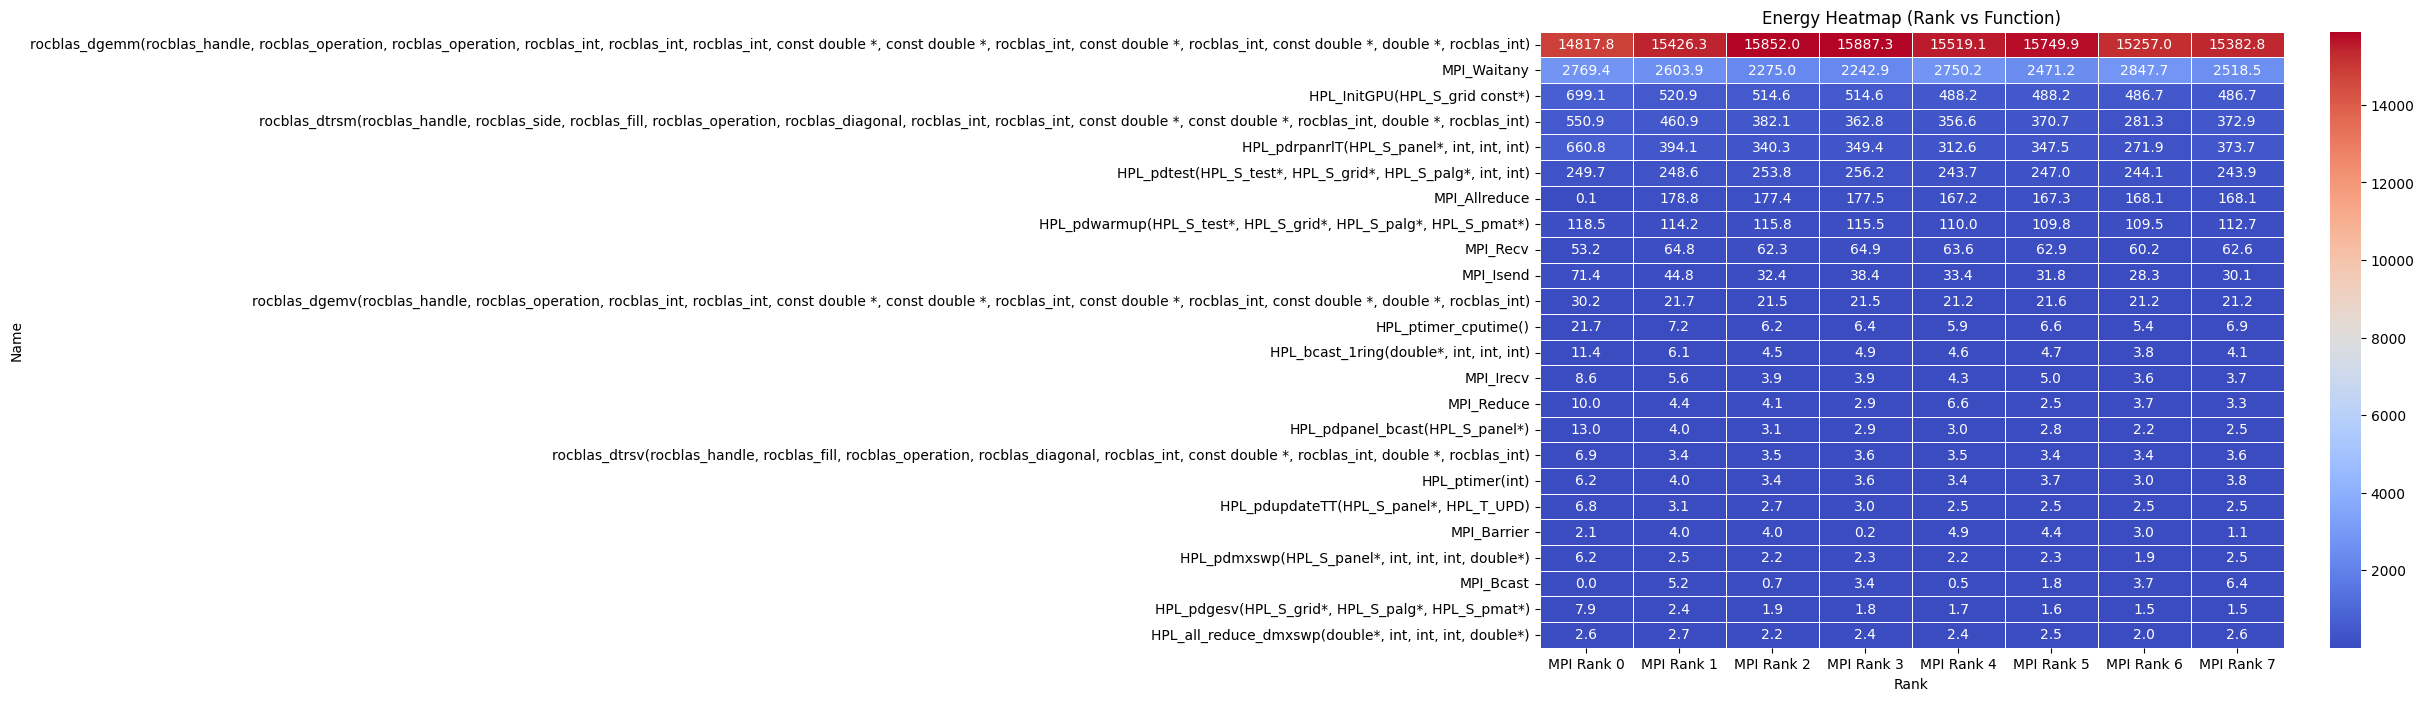

In [8]:
# Visualize Heatmap of Rates
Visualizer.plot_heatmap(df_joules, "Energy Heatmap (Rank vs Function)", cmap='coolwarm', top_n=24, aggregation_func='sum')

This transfer will use 551 MB .


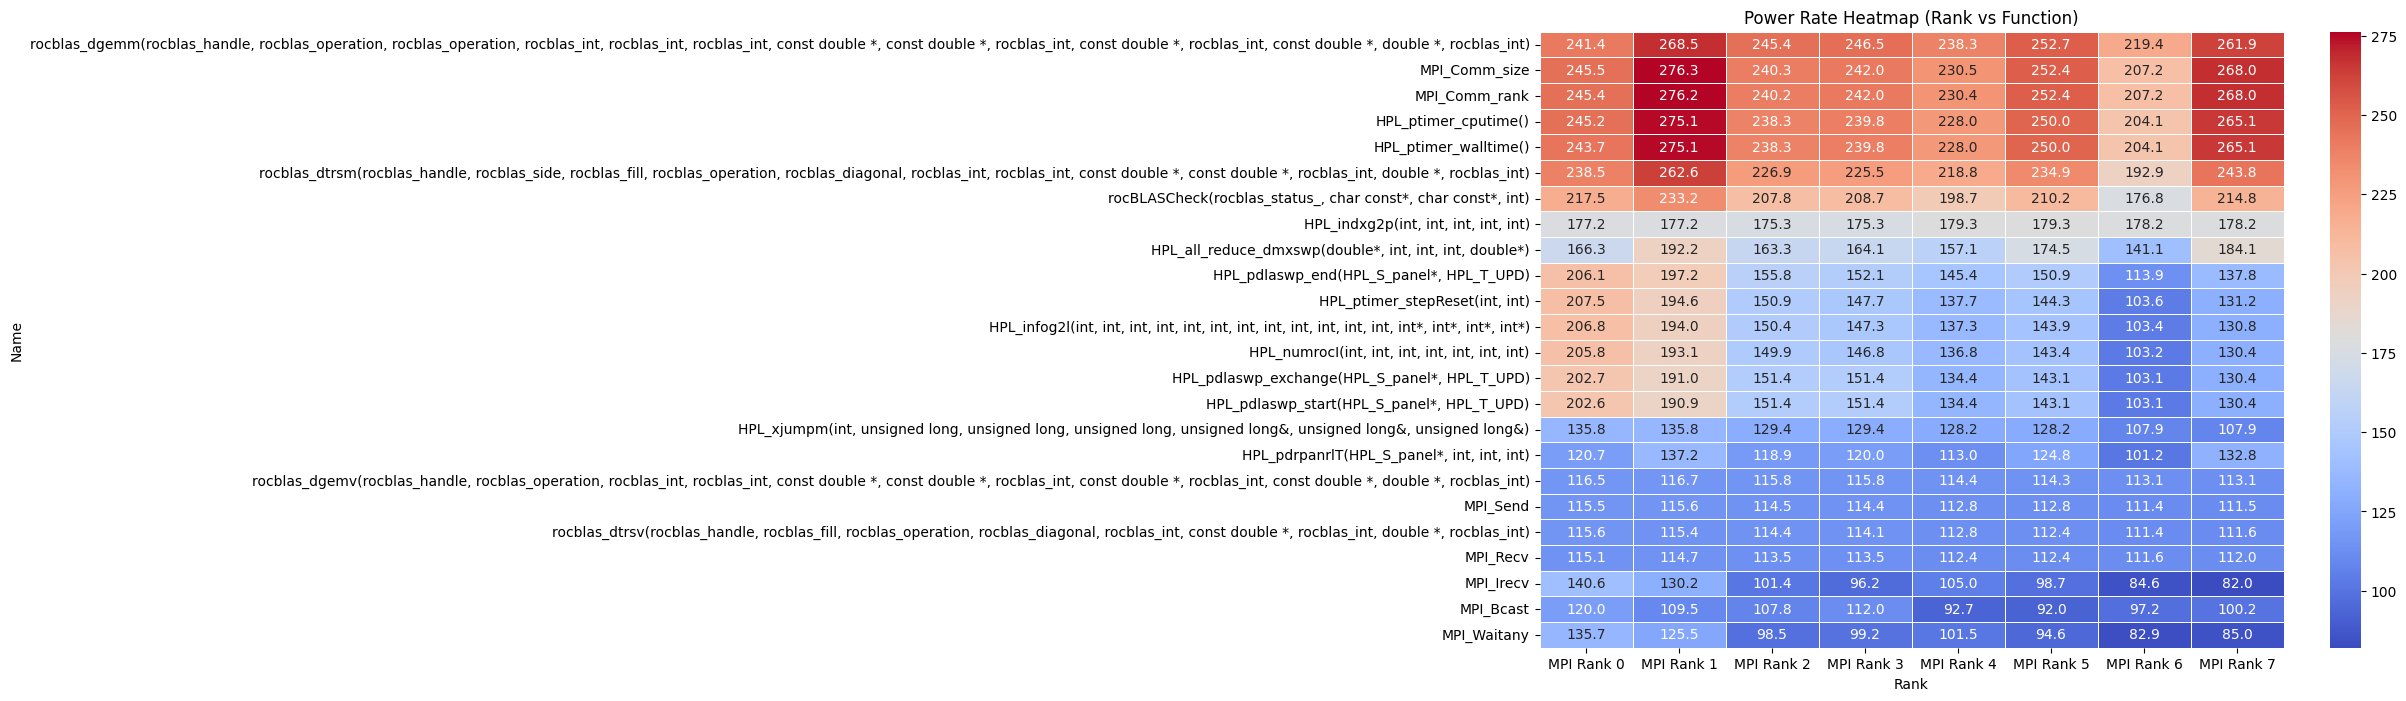

In [9]:
# Visualize Heatmap of Rates
Visualizer.plot_heatmap(df_energy_rate, "Power Rate Heatmap (Rank vs Function)", cmap='coolwarm', top_n=24, aggregation_func='mean')

In [10]:
# Visualize Flamegraph for Rank 0
print("Generating Flamegraph...")
Visualizer.plot_flamegraph(
    df_joules, 
    rank_filter="MPI Rank 0", 
    metric_name="Joules"
)

Generating Flamegraph...
This transfer will use 551 MB .


Rendering 3431 events using Optimized Rectangles...
Downsampled to 2939 visual elements (Manageable for SVG)


In [11]:
# Visualize Node View (Metrics + Flamegraphs)
print("Generating Node View...")
run = ensemble.runs[0]
node_metrics = run.nodes[0].metrics
metrics_to_plot = [m for name, m in node_metrics.items() if "energy_count" in name]

Visualizer.plot_node_view(
    attributed_df=df_joules,
    ranks=["MPI Rank 0", "MPI Rank 1"],
    metrics_data=metrics_to_plot,
    title="Node 0 Analysis: Power Lines vs Function Execution"
)

Generating Node View...
This transfer will use 551 MB .


Plotting metrics...


In [12]:
# 2. Get Average Power from Cumulative Energy Metric (using 'rate')
df_energy_rate = ak.DataFrame.concat([
    ensemble.attribute(
        metric,
        topology_resolver=my_hpc_topology,
        output_mode='rate',
        strategy='exclusive'
    ) for metric in ["A2rocm_smi:::energy_count:device=0", "A2rocm_smi:::energy_count:device=2", "A2rocm_smi:::energy_count:device=4", "A2rocm_smi:::energy_count:device=6"]
])
avg_energy_rate = df_energy_rate['Value'].mean()
print(f"Average Power (from Energy Metric): {avg_energy_rate:.2f} W")

Attributing 'A2rocm_smi:::energy_count:device=0' on Arkouda Server...


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:04<00:00,  4.82s/it]

100%|██████████| 1/1 [00:04<00:00,  4.82s/it]

Attributing 'A2rocm_smi:::energy_count:device=2' on Arkouda Server...


...

Attributing 'A2rocm_smi:::energy_count:device=6' on Arkouda Server...


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:04<00:00,  4.86s/it]

100%|██████████| 1/1 [00:04<00:00,  4.86s/it]

Average Power (from Energy Metric): 136.47 W


In [13]:
# # Visualize Distribution
# Visualizer.plot_distribution(df_energy_rate, "Power Distribution (Device 0)", bins=50)

This transfer will use 551 MB .


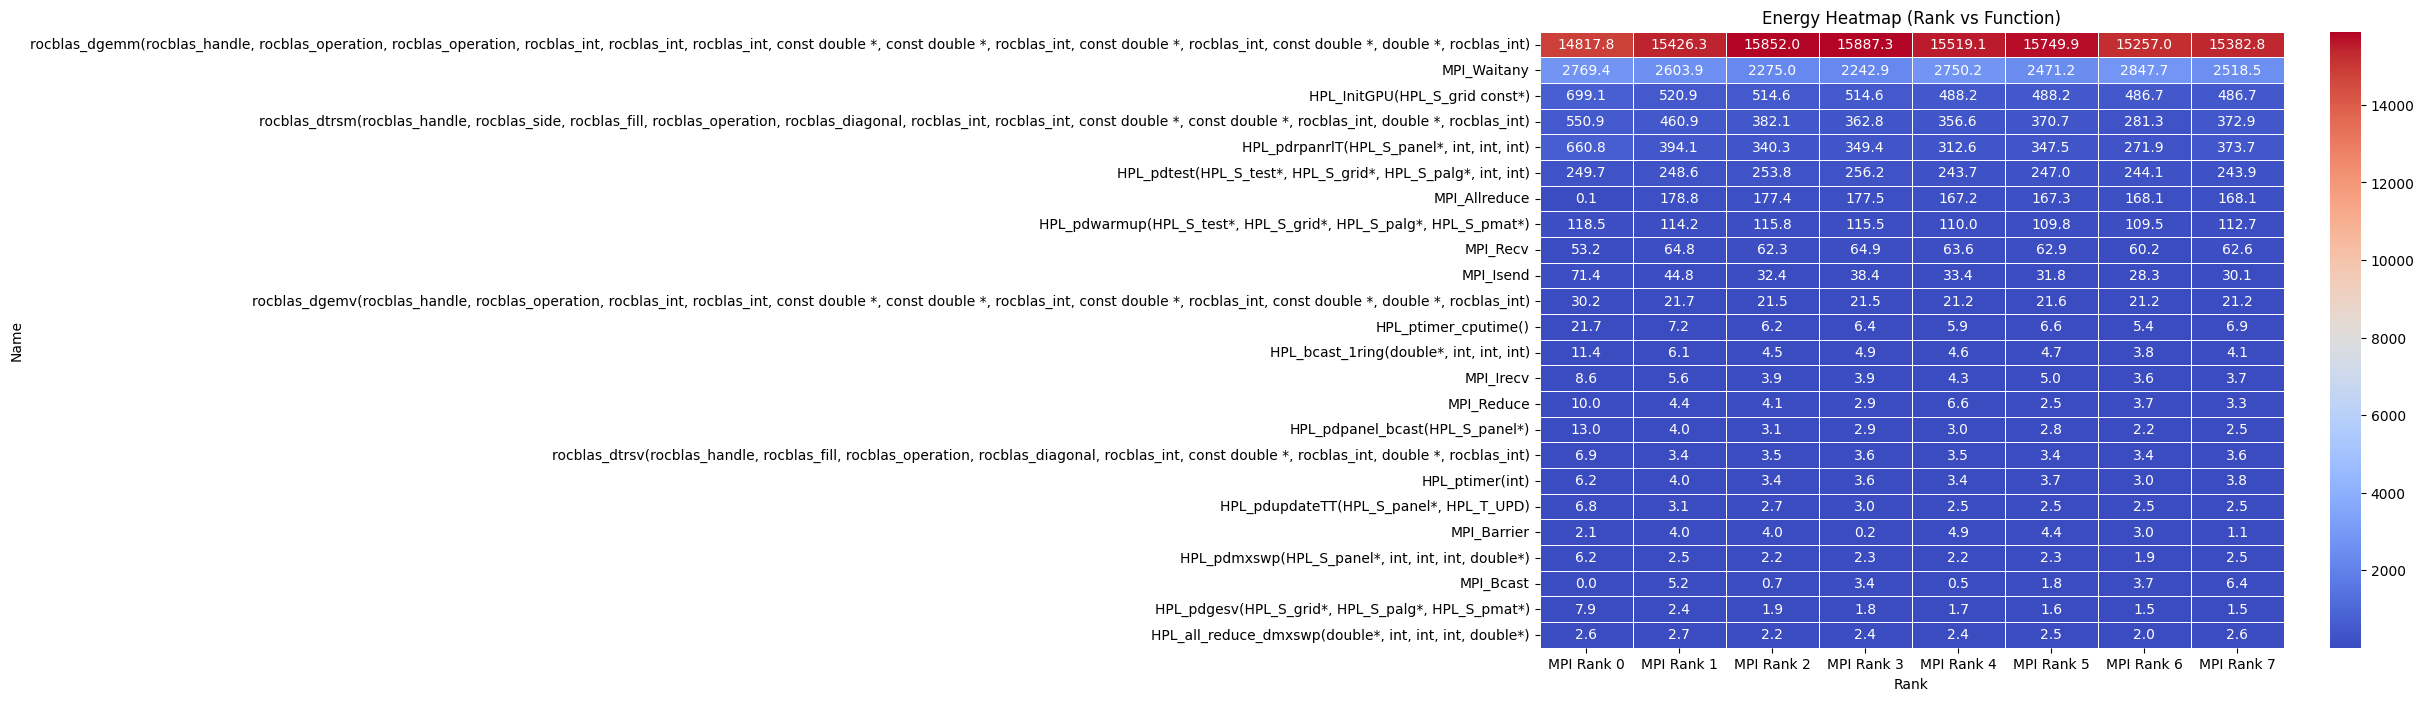

In [14]:
# Visualize Heatmap of Rates
Visualizer.plot_heatmap(df_joules, "Energy Heatmap (Rank vs Function)", cmap='coolwarm', top_n=24, aggregation_func='sum')

This transfer will use 551 MB .


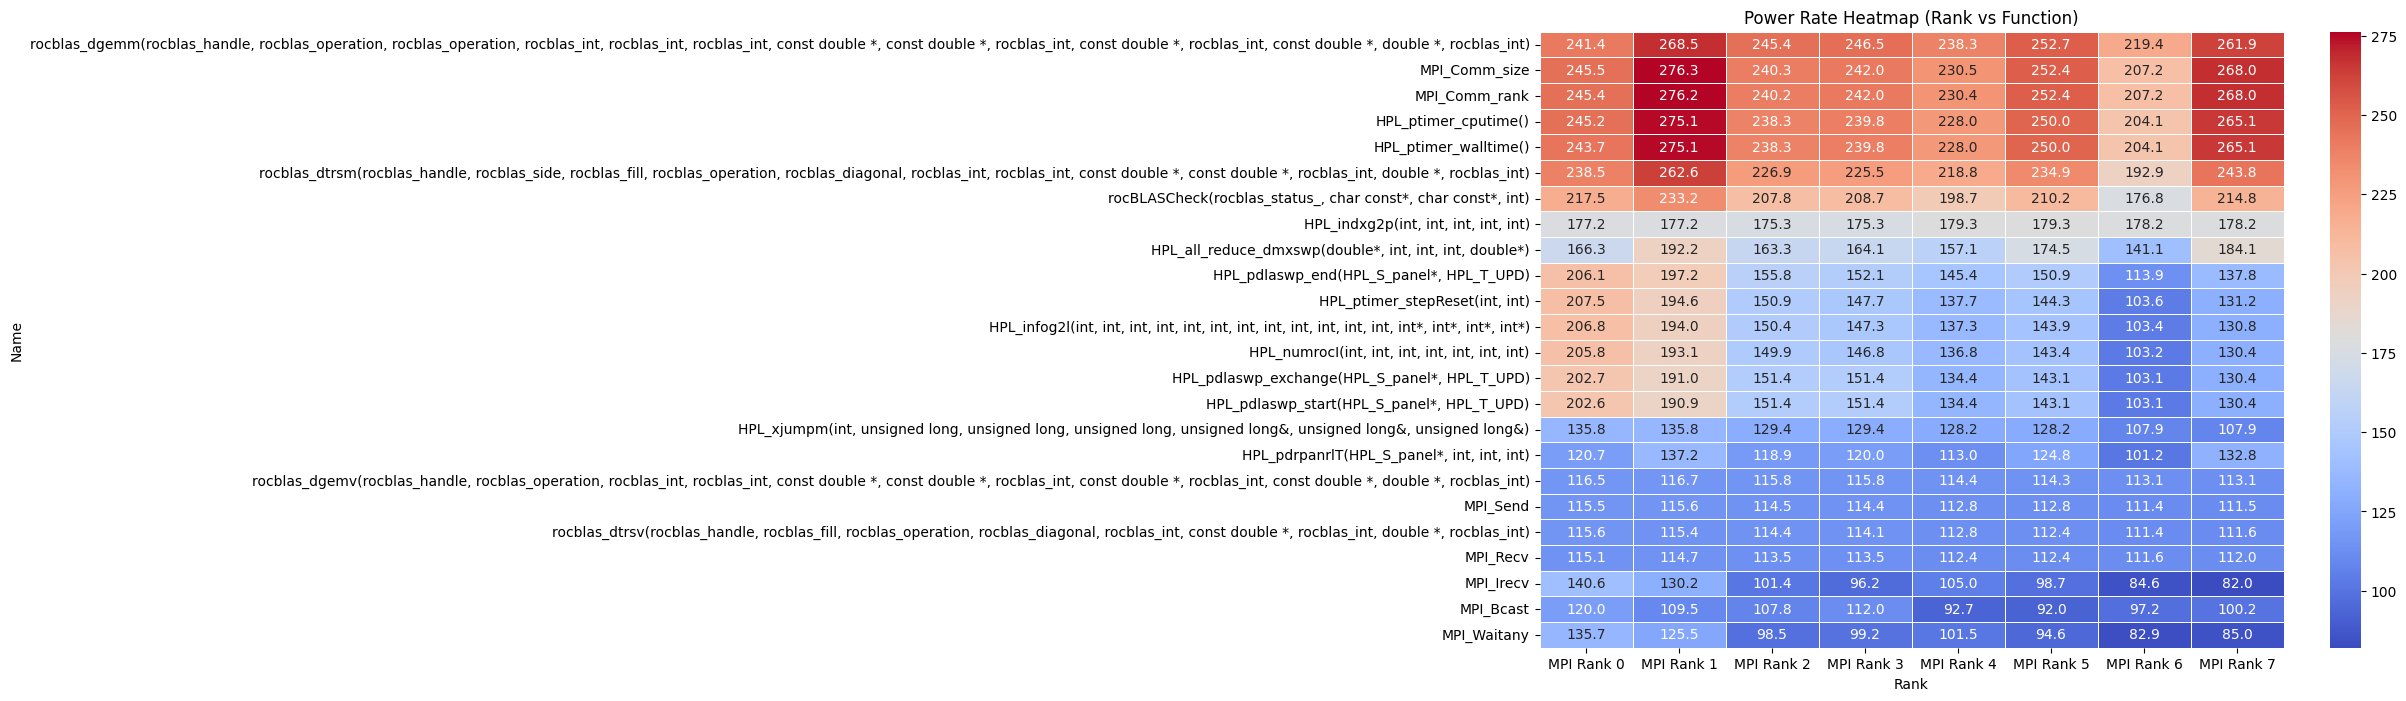

In [15]:
# Visualize Heatmap of Rates
Visualizer.plot_heatmap(df_energy_rate, "Power Rate Heatmap (Rank vs Function)", cmap='coolwarm', top_n=24, aggregation_func='mean')

In [16]:
# # 1. Define your custom logic
# def calc_power(energy_metric):
#     # Retrieve data
#     t = energy_metric.times
#     e = energy_metric.values
#     # Calculate derivative
#     dt = t[1:] - t[:-1]
#     de = e[1:] - e[:-1]
#     power = de / dt
#     # Return new Metric
#     return Metric("power", t[1:], power, MetricConfig(MetricType.INSTANTANEOUS))
    
# # 2. Register it
# ensemble.add_derived_metric("A2rocm_smi:::inst_power:device=0", calc_power, "A2rocm_smi:::energy_count:device=0")